In [54]:
!pip install -q kagglehub

import kagglehub

path = kagglehub.dataset_download(
    "sangeethakallat/chest-radiograph-images-pneumonia-and-normal"
)

print(path)

100%|██████████| 1.34G/1.34G [00:17<00:00, 84.3MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/sangeethakallat/chest-radiograph-images-pneumonia-and-normal/versions/1


## Explore Dataset Structure

In [55]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print("Folders:", dirs)
    print("Files:", len(files))
    print("-"*50)

/root/.cache/kagglehub/datasets/sangeethakallat/chest-radiograph-images-pneumonia-and-normal/versions/1
Folders: ['Pneumonia_Dataset']
Files: 0
--------------------------------------------------
/root/.cache/kagglehub/datasets/sangeethakallat/chest-radiograph-images-pneumonia-and-normal/versions/1/Pneumonia_Dataset
Folders: ['PNEUMONIA', 'NORMAL']
Files: 0
--------------------------------------------------
/root/.cache/kagglehub/datasets/sangeethakallat/chest-radiograph-images-pneumonia-and-normal/versions/1/Pneumonia_Dataset/PNEUMONIA
Folders: []
Files: 5618
--------------------------------------------------
/root/.cache/kagglehub/datasets/sangeethakallat/chest-radiograph-images-pneumonia-and-normal/versions/1/Pneumonia_Dataset/NORMAL
Folders: []
Files: 5618
--------------------------------------------------


## Import Libraries

In [57]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

## Define Dataset Path

In [58]:
dataset_path = os.path.join(path, "Pneumonia_Dataset")

## Load Training Data

In [59]:
train = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128,128),
    batch_size=32
)

Found 11236 files belonging to 2 classes.
Using 8989 files for training.


## Load Validation Data

In [60]:
validation = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128,128),
    batch_size=32
)

Found 11236 files belonging to 2 classes.
Using 2247 files for validation.


## Display Class Names

In [61]:
class_names = train.class_names
print(class_names)

['NORMAL', 'PNEUMONIA']


## Visualize Sample Images

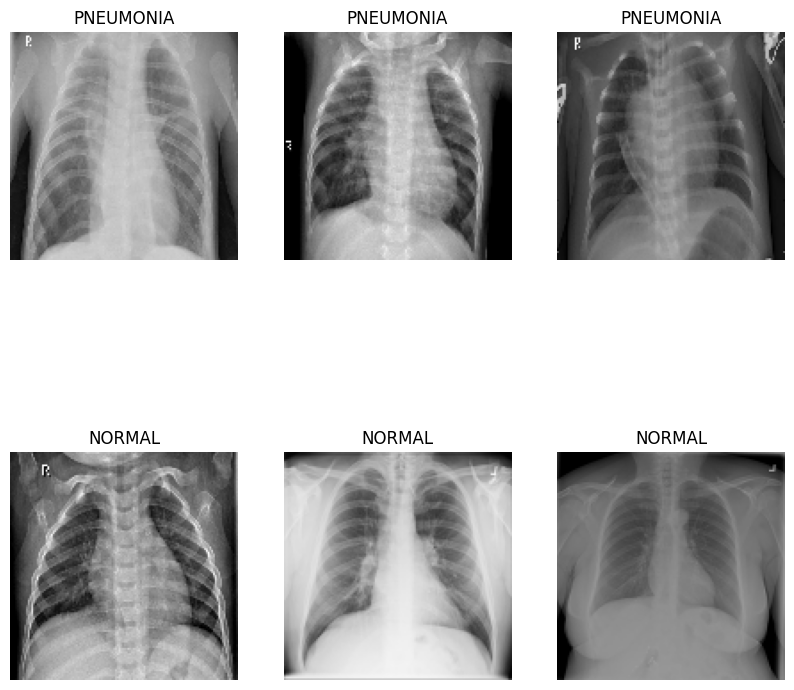

In [62]:
plt.figure(figsize=(10,10))

for images, labels in train.take(1):
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

## Normalize Image Data

In [63]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train = train.map(lambda x, y: (normalization_layer(x), y))
validation = validation.map(lambda x, y: (normalization_layer(x), y))

## Define CNN Model Architecture

In [64]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64,activation='relu'),

    tf.keras.layers.Dense(1,activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile Model

In [65]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Train Model

In [66]:
history = model.fit(
    train,
    validation_data=validation,
    epochs=5
)

Epoch 1/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 47s 157ms/step - accuracy: 0.9101 - loss: 0.2246 - val_accuracy: 0.9386 - val_loss: 0.1593
Epoch 2/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 40s 144ms/step - accuracy: 0.9566 - loss: 0.1222 - val_accuracy: 0.9595 - val_loss: 0.1114
Epoch 3/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 40s 143ms/step - accuracy: 0.9691 - loss: 0.0870 - val_accuracy: 0.9568 - val_loss: 0.1158
Epoch 4/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 43s 154ms/step - accuracy: 0.9764 - loss: 0.0691 - val_accuracy: 0.9577 - val_loss: 0.1136
Epoch 5/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 42s 150ms/step - accuracy: 0.9821 - loss: 0.0504 - val_accuracy: 0.9737 - val_loss: 0.0793


## Plot Training and Validation Accuracy

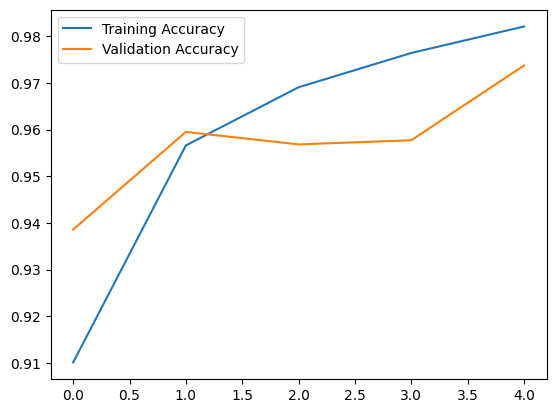

In [67]:
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.legend()
plt.show()

## Evaluate Model

In [74]:
loss, accuracy = model.evaluate(validation)

print("Test Accuracy :", accuracy)
print("loss :", loss)

71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.9737 - loss: 0.0793
Test Accuracy : 0.9737427830696106
loss : 0.07933706045150757


## Make a Prediction on a Single Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediction: PNEUMONIA


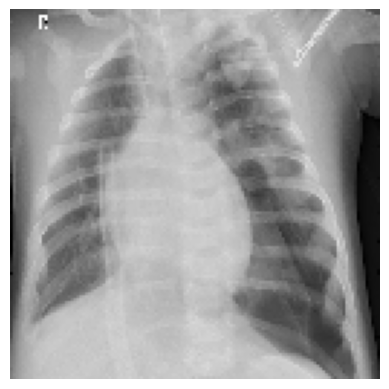

In [73]:
import numpy as np

image_path = os.path.join(dataset_path, "PNEUMONIA",
                          os.listdir(os.path.join(dataset_path,"PNEUMONIA"))[0])

img = tf.keras.preprocessing.image.load_img(
    image_path,
    target_size=(128,128)
)

plt.imshow(img)
plt.axis("off")

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array,0)/255

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: PNEUMONIA")
else:
    print("Prediction: NORMAL")